# Assignment 9
Darsh Ambade - MS22068

## Question 1
Detection of COCO objects using YOLOv8

The ultralytics package is used for ease. The model and image are imported from the package itself.

In [18]:
import cv2
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

IMAGES = [
    "https://ultralytics.com/images/bus.jpg"
]

with open("q1_detection_results.txt", "w") as f:
    for r in model.predict(source=IMAGES, verbose=False, save=False):
        img = r.orig_img.copy()
        name = r.path.split("/")[-1]

        f.write(f"image: {name}\n")

        for box in r.boxes:
            label = model.names[int(box.cls[0])]
            conf  = round(float(box.conf[0]), 2)
            x1, y1, x2, y2 = [int(v) for v in box.xyxy[0]]

            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, f"{label} {conf}", (x1, y1 - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

            f.write(f"  {label}  conf={conf}  bbox=({x1},{y1},{x2},{y2})\n")

        f.write("\n")
        cv2.imwrite(name, img)
        print(f"saved {name}")

print("saved q1_detection_results.txt")

saved image0.jpg
saved q1_detection_results.txt


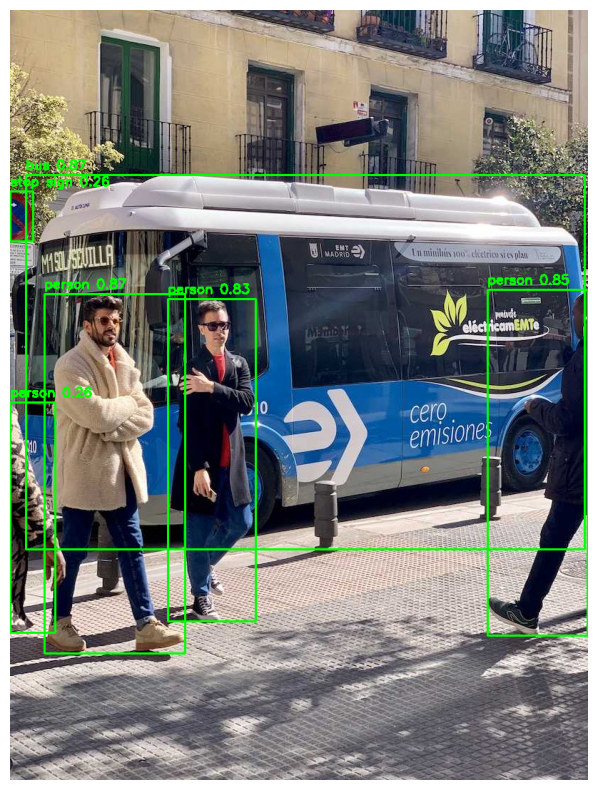

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Another test is done on a video i took of my desk. Unlike the test above which uses sample images from the dataset, a custom video truely tests the capabiliity of the model

The annoated video can be found here: 

In [20]:
model = YOLO("yolov8n.pt")

input_video_path = "rec_video.mp4"
output_video_path = "annotated_video.mp4"

cap = cv2.VideoCapture(input_video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
cap.release()

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

frame_count = 0

with open("q1_video_detection_results.txt", "w") as f:
    for r in model.predict(source=input_video_path, stream=True, verbose=False):
        frame_count += 1
        f.write(f"Frame: {frame_count}\n")
        
        img = r.orig_img.copy()
        
        for box in r.boxes:
            label = model.names[int(box.cls[0])]
            conf = round(float(box.conf[0]), 2)
            x1, y1, x2, y2 = [int(v) for v in box.xyxy[0]]
            
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, f"{label} {conf}", (x1, y1 - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
            
            f.write(f"  {label}  conf={conf}  bbox=({x1},{y1},{x2},{y2})\n")
            
        f.write("\n")
        out.write(img)

out.release()

The first frame of the output annotated video

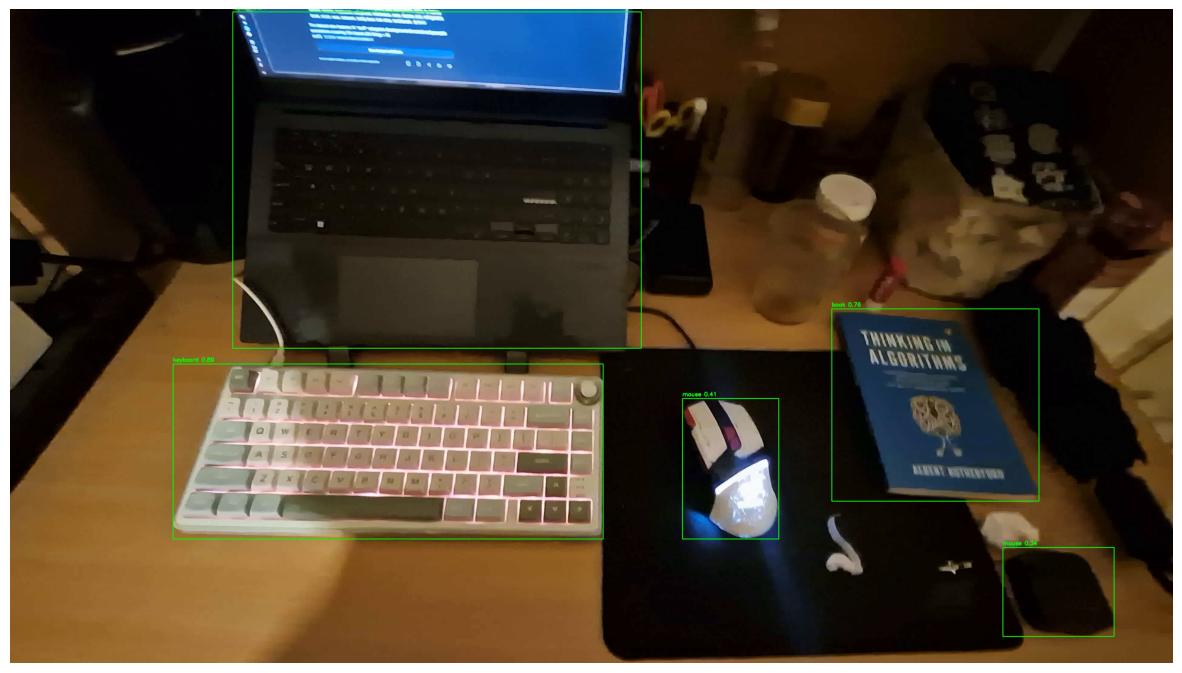

In [21]:
cap = cv2.VideoCapture("annotated_video.mp4")
ret, img = cap.read()
cap.release()

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

---

## Question 2
A video of cars in traffic is used for the question captured from a still overhead camera

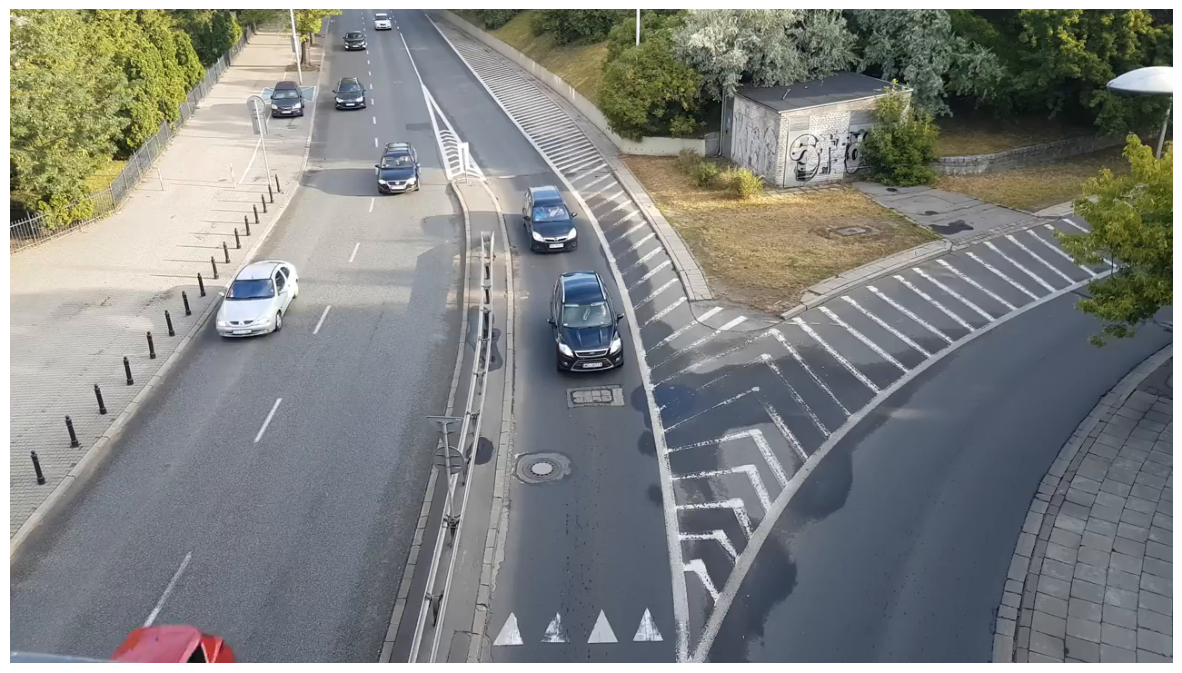

In [22]:
cap = cv2.VideoCapture("video.mp4")
ret, img = cap.read()
cap.release()

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [23]:
import os
import cv2

VIDEO_PATH = "video.mp4"
OUTPUT_DIR = "frames"

cap = cv2.VideoCapture(VIDEO_PATH)

total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# video properties
print(f"resolution : {width}x{height}")
print(f"fps        : {fps:.2f}")
print(f"frames     : {total}")
print(f"duration   : {total/fps:.2f}s")

os.makedirs(OUTPUT_DIR, exist_ok=True)

frame_number = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    cv2.imwrite(os.path.join(OUTPUT_DIR, f"frame_{frame_number:05d}.jpg"), frame)
    frame_number += 1

cap.release()

# jpg file properties from the first saved frame
sample = cv2.imread(os.path.join(OUTPUT_DIR, "frame_00000.jpg"))
size_kb = os.path.getsize(os.path.join(OUTPUT_DIR, "frame_00000.jpg")) / 1024

print(f"\nextracted {frame_number} frames to {OUTPUT_DIR}/")
print(f"jpg resolution : {sample.shape[1]}x{sample.shape[0]}")
print(f"jpg channels   : {sample.shape[2]} (BGR)")
print(f"jpg size       : ~{size_kb:.1f} KB per frame")

resolution : 1280x720
fps        : 30.00
frames     : 9187
duration   : 306.23s

extracted 9184 frames to frames/
jpg resolution : 1280x720
jpg channels   : 3 (BGR)
jpg size       : ~381.7 KB per frame


---

## Question 3
1. Annotation is the process of labeling raw data with ground truth.
     Supervised models need labeled examples to learn from, without
     annotations a model has no idea what objects are or where they are.
     For object detection, annotations give both the class and the bounding box.

In [24]:
import os
import json
import csv

FRAMES_DIR = "annotated_frames"
OUTPUT_CSV = "annotations.csv"

rows = []

for filename in sorted(os.listdir(FRAMES_DIR)):
    if not filename.endswith(".json"):
        continue

    with open(os.path.join(FRAMES_DIR, filename)) as f:
        data = json.load(f)

    image_name = data.get("imagePath", filename.replace(".json", ".jpg"))

    for shape in data.get("shapes", []):
        points = shape["points"]
        xs = [p[0] for p in points]
        ys = [p[1] for p in points]
        rows.append({
            "image": image_name,
            "label": shape["label"],
            "shape_type": shape.get("shape_type", "polygon"),
            "x_min": round(min(xs), 1),
            "y_min": round(min(ys), 1),
            "x_max": round(max(xs), 1),
            "y_max": round(max(ys), 1),
        })

if not rows:
    print("no JSON annotations found — annotate in labelme first")
else:
    with open(OUTPUT_CSV, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["image", "label", "shape_type",
                                                "x_min", "y_min", "x_max", "y_max"])
        writer.writeheader()
        writer.writerows(rows)
    print(f"saved {len(rows)} annotations to {OUTPUT_CSV}")

saved 33 annotations to annotations.csv


The Car video from Question-02 is annotated below:

In [25]:
import pandas as pd
df = pd.read_csv(OUTPUT_CSV)
print(df)

                        image label shape_type  x_min  y_min  x_max  y_max
0   ../frames/frame_00000.jpg   Car  rectangle  215.7  253.5  327.8  378.7
1   ../frames/frame_00000.jpg   Car  rectangle  545.2  180.4  639.1  277.0
2   ../frames/frame_00000.jpg   Car  rectangle  580.9  286.5  683.5  423.0
3   ../frames/frame_00000.jpg   Car  rectangle  398.3  131.7  457.4  210.0
4   ../frames/frame_00000.jpg   Car  rectangle  273.9   69.1  333.9  131.7
5   ../frames/frame_00000.jpg   Car  rectangle  349.6   64.8  396.5  123.0
6   ../frames/frame_00000.jpg   Car  rectangle  354.8   19.6  399.1   52.6
7   ../frames/frame_00000.jpg   Car  rectangle  394.8    3.0  426.1   24.8
8   ../frames/frame_00000.jpg   Car  rectangle  116.5  665.7  256.5  720.0
9   ../frames/frame_00001.jpg   Car  rectangle  223.5  270.0  315.7  380.4
10  ../frames/frame_00001.jpg   Car  rectangle  585.2  283.0  680.0  419.6
11  ../frames/frame_00001.jpg   Car  rectangle  553.0  187.4  640.0  276.1
12  ../frames/frame_00001

---